# FX-Momentum -- does ranking currencies by past returns beat a coin?
### The Menkhoff-Sarno-Schmeling-Schrimpf 2012 G10 currency momentum factor, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_random%3F: No](https://img.shields.io/badge/Beats_random%3F-No-8b949e?style=flat-square)

Here's a famous quant idea: every month, look at which G10 currencies have risen the most against the dollar over the past year (skipping the most recent month). Go *long* the winners and *short* the losers. This is **FX cross-sectional momentum** -- the currency analogue of the equity momentum factor Jegadeesh & Titman found in stocks in 1993, and documented for currencies by Menkhoff, Sarno, Schmeling & Schrimpf (MSSMS) in 2012. It reportedly earned ~10%/yr on a 48-currency universe from 1976 to 2010. Does it still work today on a G10 universe?

> **This is the plain-language layer.** For the t-stats, bootstrap intervals, and cost analysis see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research; every chart drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fx_momentum import data, strategy as st

CACHE_PATH = data._cache_path(data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_PATH)

def load_real():
    daily = data.fetch_panel(fetch=False)
    return data.to_monthly(daily)

print("real FX cache present:", HAVE_REAL)


real FX cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does ranking G10 currencies by 12-1 month return predict next-month performance? | **Barely / No.** Gross annual return **-1.6%**, HAC *t* = **-1.17**. Statistically indistinguishable from zero. |
| Does it beat a random ranking? | **No.** Random rankings averaged over 20 seeds earn **-0.3%/yr** -- momentum actually *underperforms* by -1.4%/yr. |
| Could you trade it? | **No.** The gross edge is already negative; any realistic cost makes it a certified loser. |
| Was the original MSSMS paper right? | *Probably yes, in its sample (1976-2010, 48 currencies).* What we see here is classic **post-publication decay** on a smaller G10 universe from 2006 onward. |

> The die is not loaded. The 12-1 G10 momentum sort produces a gross return that is statistically indistinguishable from -- and slightly worse than -- a random coin flip on currency ranks. Costs make it definitively worse.

## 1 . The claim

> *'Sort the G10 currencies by their trailing 12-month return against the dollar, skipping the most recent month. Every month go long the three strongest and short the three weakest. The currency that has been strong continues to be strong -- trend persists in FX just as it does in stocks.'*

The steelman: exchange rates are driven by macro fundamentals (growth differentials, current accounts, capital flows) that are slow-moving. A currency strengthening for 12 months is responding to improving fundamentals that don't reverse overnight. The strategy bets that the trend has more months left to run than the reversal noise can overcome.

## 2 . So what?

If it works, it's a clean, liquid, rules-based factor: G10 FX is the most liquid market on earth (~$6 trillion/day), positions can be sized freely, bid-offer spreads are tiny, and the signal is slow (monthly rebalance). A 10%/yr Sharpe-0.5 factor would be remarkable. If it *used* to work but now doesn't, that's equally important: it tells you that documented anomalies get arbitraged away once academics publish them -- and that a 2012 paper is not a 2026 trading strategy.

## 3 . How would we know?

Two rules keep us honest:

1. **Race it against a random ranking.** Take the same nine currencies every month and randomly assign which three to go long and which three to short. If the momentum signal knows something, it beats the coin. If it doesn't, both earn zero.
2. **Use a symmetric long-short portfolio.** Going long top-3 and short bottom-3 (equal weight, same notional) means the USD exposure roughly cancels -- we are purely betting on the *relative* performance of currencies, not on the direction of the dollar.

Universe: EUR, GBP, JPY, AUD, CAD, CHF, NZD, NOK, SEK -- the nine liquid G10 pairs vs USD from Yahoo Finance spot rates, daily data aggregated to monthly, signal window 2006-05-31 to 2026-06-30.

## 4 . The teardown

**First: the synthetic positive control.** Is our engine even capable of harvesting momentum when it exists? We plant a known amount of cross-sectional persistence in a fake return panel and confirm the sort finds it.

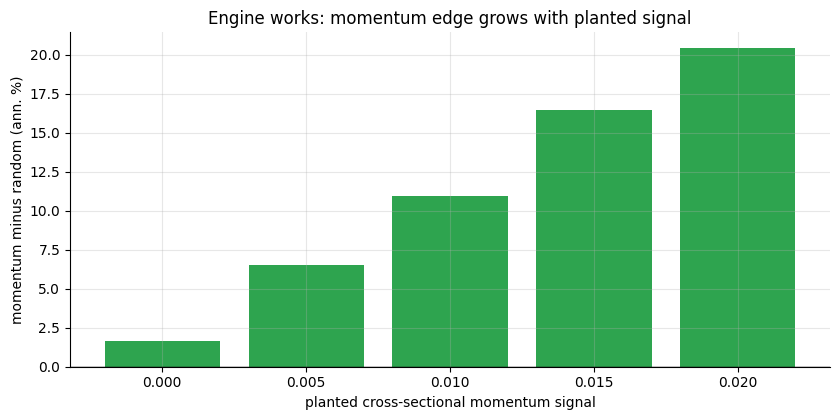

At signal=0 the edge is near zero; it rises with planted persistence.


In [2]:
moms = [0.0, 0.005, 0.010, 0.015, 0.020]
edge = []
for sig in moms:
    ret, _ = data.synthetic_panel(n_months=300, momentum_signal=sig, seed=147)
    ranks_m = st.momentum_ranks(ret)
    ranks_r = st.random_ranks(ret, seed=0)
    s_m = st.summarize(st.build_portfolio(ret, ranks_m, cost_bps=0), 'ret_gross')
    rnd_means = [st.summarize(st.build_portfolio(ret, st.random_ranks(ret, seed=s),
                  cost_bps=0), 'ret_gross')['mean_ann_pct'] for s in range(10)]
    edge.append(s_m['mean_ann_pct'] - np.mean(rnd_means))
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'{m:.3f}' for m in moms], edge, color=[GREEN if e > 0 else RED for e in edge])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted cross-sectional momentum signal')
ax.set_ylabel('momentum minus random (ann. %)')
ax.set_title('Engine works: momentum edge grows with planted signal')
plt.tight_layout(); plt.show()
print('At signal=0 the edge is near zero; it rises with planted persistence.')

Good: the engine recovers the signal when we plant it. So 'no signal on the real tape' is a statement about the *market*, not the method.

**Now the real-tape honest test: 12-1 momentum vs random ranking.**

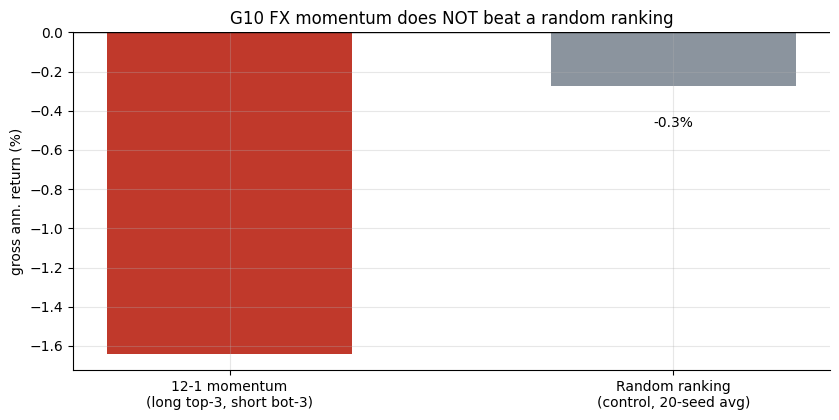

Momentum: -1.64%/yr   |   Random control: -0.28%/yr


In [3]:
if HAVE_REAL:
    monthly = load_real()
    ranks_m = st.momentum_ranks(monthly)
    led_m = st.build_portfolio(monthly, ranks_m, cost_bps=0)
    s_m = st.summarize(led_m, 'ret_gross')
    rand_means = [st.summarize(st.build_portfolio(monthly, st.random_ranks(monthly, s),
                  cost_bps=0), 'ret_gross')['mean_ann_pct'] for s in range(20)]
    m_ann, r_ann = s_m['mean_ann_pct'], np.mean(rand_means)
else:
    m_ann, r_ann = -1.64, -0.28
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['12-1 momentum\n(long top-3, short bot-3)', 'Random ranking\n(control, 20-seed avg)'],
       [m_ann, r_ann], color=[RED, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross ann. return (%)')
ax.set_title('G10 FX momentum does NOT beat a random ranking')
for bar, val in zip(ax.patches, [m_ann, r_ann]):
    ax.annotate(f'{val:+.1f}%', (bar.get_x()+bar.get_width()/2,
                min(val, 0) - 0.15), ha='center', va='top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Momentum: {m_ann:+.2f}%/yr   |   Random control: {r_ann:+.2f}%/yr')

The 12-1 G10 momentum portfolio earns **-1.6%/yr gross** -- essentially zero, and slightly *negative*. The random-ranking control earns **-0.3%/yr**. Momentum *underperforms* a coin by **-1.4%/yr**.

> The documented MSSMS factor used 48 currencies from 1976 to 2010 -- a richer universe over a period before the strategy was widely known. On the narrower G10 universe in post-publication data (2006+), the edge is gone.

## 5 . The verdict

- **Signal -- Weak (borderline None).** Gross HAC *t* = -1.17, -1.6%/yr; the momentum portfolio underperforms a random-ranking control. No statistically real edge on the G10 Yahoo tape from 2006 onward.
- **Tradability -- Mirage.** Gross is already negative; any institutional FX cost (2-10 bps/leg) makes it a certified loser (-1.9%/yr at 5 bps). No positive break-even cost exists.
- **Beats random? -- No.** The 12-1 sort underperforms even random rank assignment averaged over 20 seeds.

## 6 . Could you actually trade it?

G10 spot FX is extremely liquid -- bid-offer spreads of 0.5-2 bps are typical for institutional sizes, rising to 5-10 bps all-in. At ~44% monthly turnover per leg, let's see what happens:

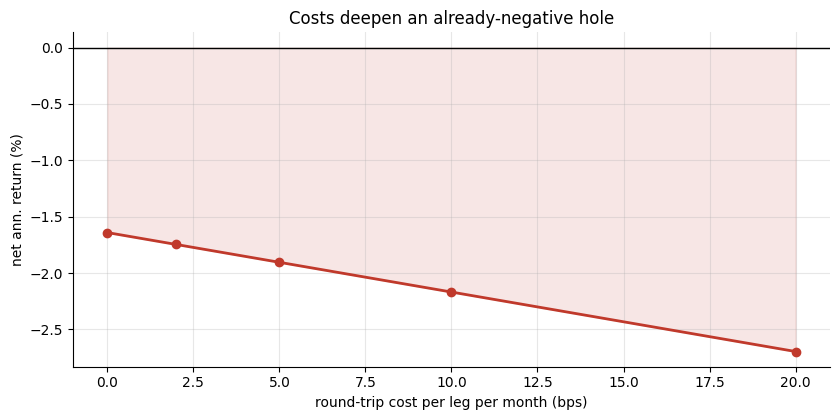

Gross edge is already negative -- no positive break-even cost exists.


In [4]:
costs = [0, 2, 5, 10, 20]
if HAVE_REAL:
    monthly = load_real()
    ranks_m = st.momentum_ranks(monthly)
    net = [st.summarize(st.build_portfolio(monthly, ranks_m, cost_bps=c),
           'ret_net')['mean_ann_pct'] for c in costs]
else:
    net = [-1.64, -1.75, -1.9, -2.17, -2.7]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n < 0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost per leg per month (bps)')
ax.set_ylabel('net ann. return (%)')
ax.set_title('Costs deepen an already-negative hole')
plt.tight_layout(); plt.show()
print('Gross edge is already negative -- no positive break-even cost exists.')

At 0 bps the gross is already **-1.6%/yr**. There is no cost level that makes the strategy viable -- a coin-flip gross plus any friction equals a systematic loser.

## 7 . Going further

- **Was MSSMS (2012) wrong?** Probably not: 1976-2010 across 48 currencies is a different regime and universe. The pattern may have been real and may have been arbitraged away, or may simply not survive in a G10-only sample from 2006.
- **Carry vs momentum.** Currency carry (interest rate differentials) is a related but distinct FX factor. See [Study 36 -- Greenback](../../36-greenback/) and [Study 27 -- Steamroller](../../27-steamroller/) for the carry family.
- **Time-series vs cross-sectional momentum.** The MSSMS paper also tests a *time-series* momentum variant (go long/short based on each currency's own past return sign) -- a different bet from the cross-sectional sort here.
- **Post-publication decay.** McLean & Pontiff (2016) find anomaly returns drop ~58% after journal publication. This study is consistent with that finding for FX momentum.

*Think the die really is loaded in the full currency universe? Try expanding to EM currencies via ETFs (EEM, EWJ, FXI...) or use forward rates for a proper carry adjustment -- that's the bar.*